In [ ]:
# Cell 1: Kaggle setup
!pip install -q kaggle

# Cell 2: Upload kaggle.json (ye Colab mein ek file upload hogi bas)
from google.colab import files
files.upload()  # yahan kaggle.json upload karna

# Cell 3: Setup and download
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d medahmedkrichen/devanagari-handwritten-character-datase
!unzip -q devanagari-handwritten-character-datase.zip -d /content/devanagari_data

Saving archive (3).zip to archive (3).zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/medahmedkrichen/devanagari-handwritten-character-datase
License(s): unknown
100% 76.1M/76.1M [00:05<00:00, 14.9MB/s]



In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import cv2

print("All imports done!")
print(f"TensorFlow version: {tf.__version__}")

All imports done!
TensorFlow version: 2.20.0


In [ ]:
DATA_DIR = "/content/devanagari_data"

# Auto-detect actual folder with class subfolders
for root, dirs, files in os.walk(DATA_DIR):
    if len(dirs) > 10:
        DATA_DIR = root
        break

print(f"Using: {DATA_DIR}")

IMG_SIZE = 32
images = []
labels = []
class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
print(f"Found {len(class_names)} classes")

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(DATA_DIR, class_name)
    files = [f for f in os.listdir(class_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    for fname in files:
        img = cv2.imread(os.path.join(class_path, fname), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)
            labels.append(idx)

images = np.array(images).astype('float32') / 255.0
images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)
labels = np.array(labels)

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Total: {len(images)} | Train: {len(X_train)} | Test: {len(X_test)} | Classes: {num_classes}")

Using: /content/devanagari_data/DevanagariHandwrittenCharacterDataset/Test
Found 46 classes
Total: 13800 | Train: 11040 | Test: 2760 | Classes: 46


In [ ]:

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])

datagen = ImageDataGenerator(rotation_range=10, width_shift_range=0.1,
                             height_shift_range=0.1, zoom_range=0.1)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(datagen.flow(X_train, y_train_cat, batch_size=64),
                    epochs=25, validation_data=(X_test, y_test_cat),
                    callbacks=callbacks, verbose=1)

print("Training done!")

Epoch 1/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - accuracy: 0.1684 - loss: 3.3325 - val_accuracy: 0.0312 - val_loss: 5.5104 - learning_rate: 0.0010
Epoch 2/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4426 - loss: 1.9286 - val_accuracy: 0.1004 - val_loss: 5.1870 - learning_rate: 0.0010
Epoch 3/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6194 - loss: 1.2542 - val_accuracy: 0.5214 - val_loss: 1.5919 - learning_rate: 0.0010
Epoch 4/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7226 - loss: 0.8972 - val_accuracy: 0.9101 - val_loss: 0.3123 - learning_rate: 0.0010
Epoch 5/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7752 - loss: 0.7090 - val_accuracy: 0.9326 - val_loss: 0.2218 - learning_rate: 0.0010
Epoch 6/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8236 - loss: 0.5637 - val_accuracy: 0.9388 - val_loss: 0.1811 - learning_rate: 0.0010
Epoch 7/25
173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.8516 - loss: 0

87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Clean Test Accuracy: 98.91%
Clean          : 98.91%  (drop: 0.00%)
Blur 3x3       : 97.83%  (drop: 1.09%)
Blur 5x5       : 95.36%  (drop: 3.55%)
Noise 5%       : 12.79%  (drop: 86.12%)
Noise 10%      : 7.46%  (drop: 91.45%)
Rotate +10     : 66.49%  (drop: 32.43%)
Rotate +20     : 42.54%  (drop: 56.38%)
Rotate -10     : 40.11%  (drop: 58.80%)
Bright 1.5x    : 97.64%  (drop: 1.27%)
Bright 0.5x    : 97.14%  (drop: 1.78%)


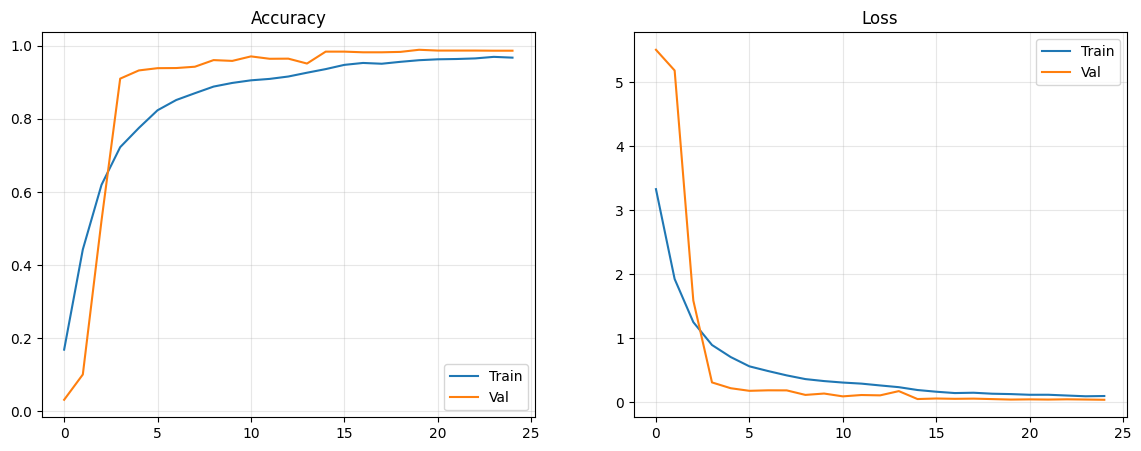

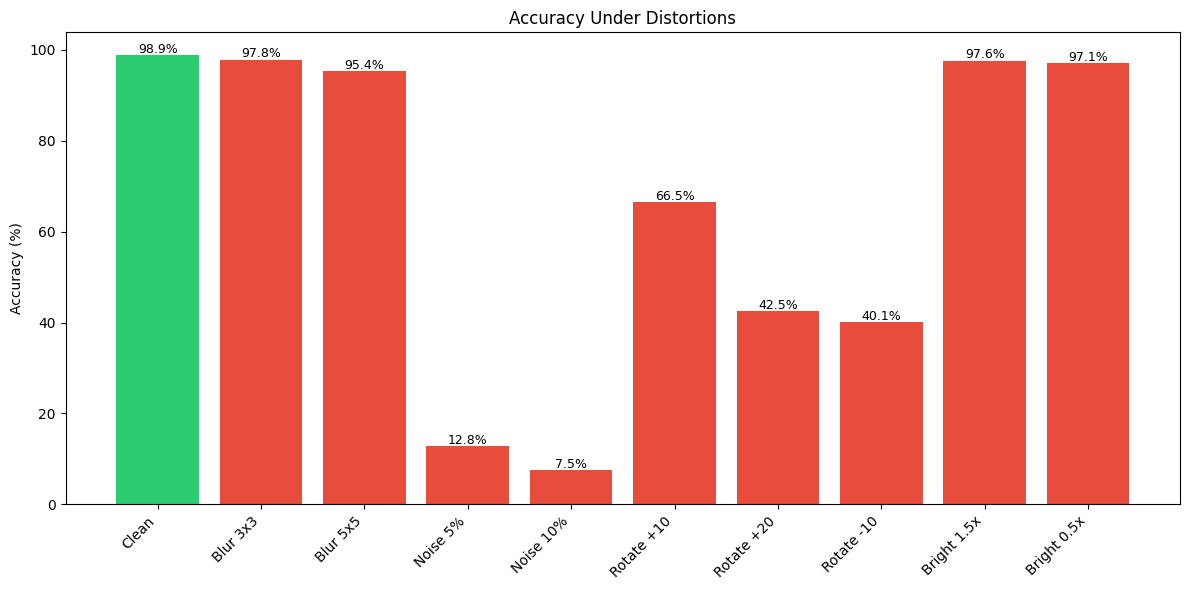

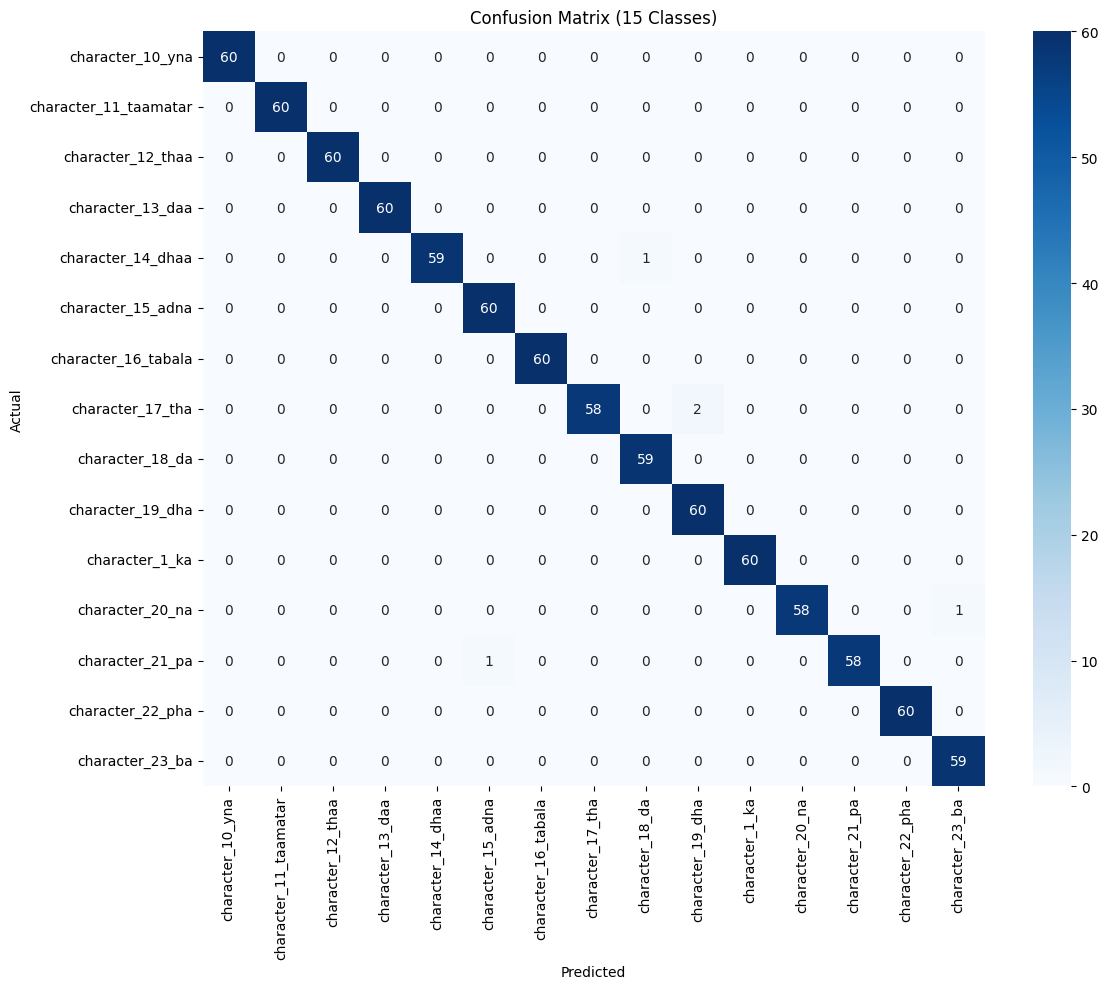

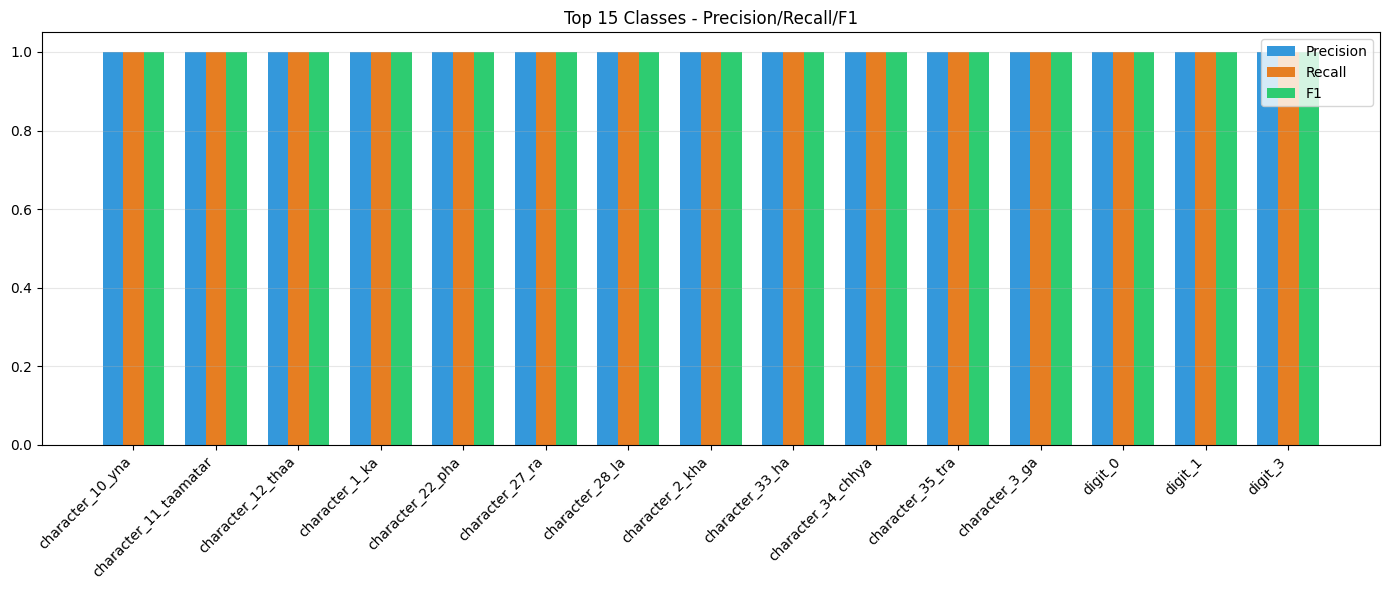

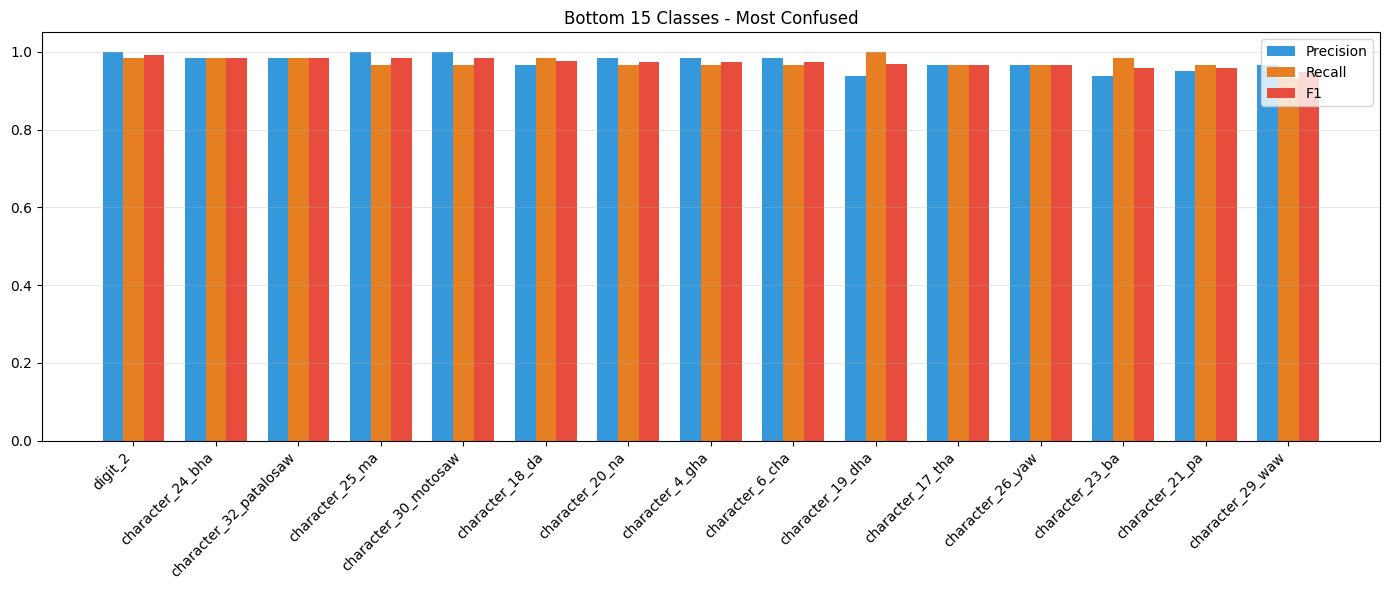

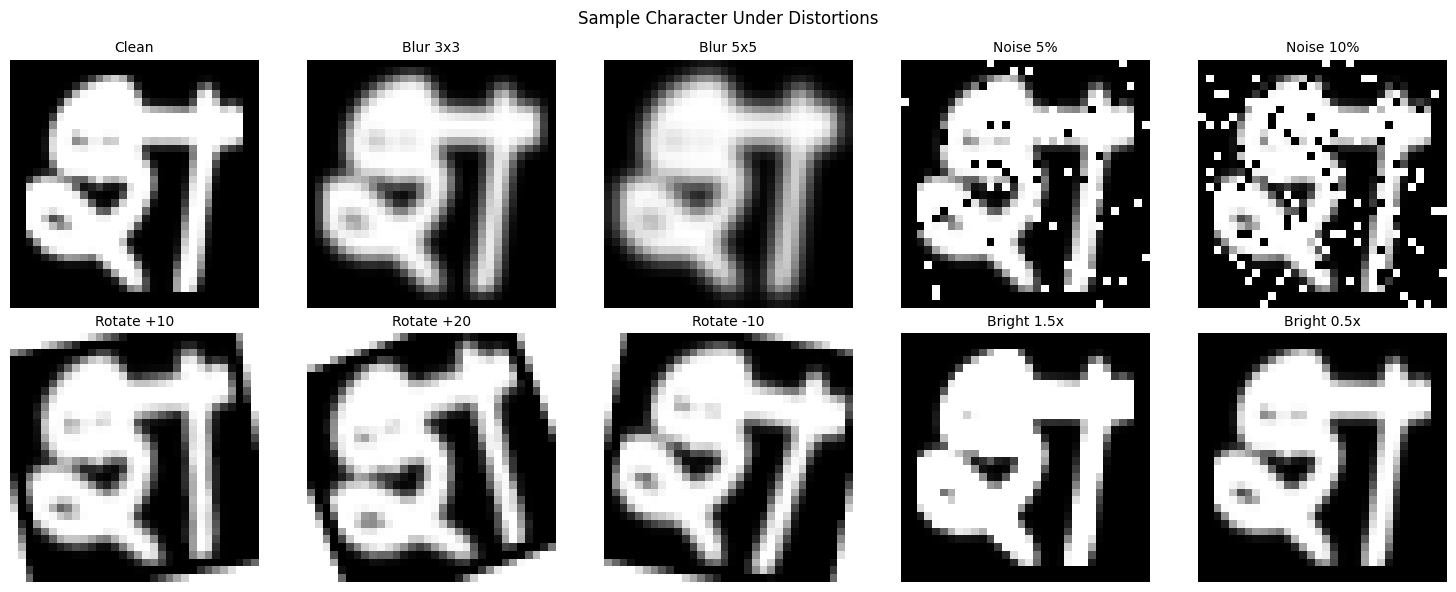



TABLE 4: Hyperparameters
Architecture: Custom CNN (3 Conv blocks)
Optimizer: Adam (lr=0.001)
Loss: Categorical Cross-Entropy
Batch Size: 64
Epochs: 25
Dropout: 0.25, 0.3, 0.5
Augmentation: Rotation ±10°, Shift 10%, Zoom 10%


Overall Metrics:
Macro Precision: 0.9893
Macro Recall: 0.9891
Macro F1: 0.9891

DONE! All 6 plots saved.


In [ ]:
# Clean test accuracy
y_pred = np.argmax(model.predict(X_test), axis=1)
clean_acc = accuracy_score(y_test, y_pred)
print(f"Clean Test Accuracy: {clean_acc*100:.2f}%")

# Distortion functions
def apply_blur(imgs, k=5):
    return np.array([cv2.GaussianBlur(i.squeeze(),(k,k),0).reshape(32,32,1) for i in imgs])

def apply_noise(imgs, amt=0.05):
    out = imgs.copy()
    for i in range(len(out)):
        img = out[i].squeeze()
        n = int(amt * img.size)
        coords = [np.random.randint(0,d,n) for d in img.shape]
        img[coords[0],coords[1]] = 1.0
        coords = [np.random.randint(0,d,n) for d in img.shape]
        img[coords[0],coords[1]] = 0.0
        out[i] = img.reshape(32,32,1)
    return out

def apply_rot(imgs, angle=15):
    return np.array([cv2.warpAffine(i.squeeze(), cv2.getRotationMatrix2D((16,16),angle,1.0),(32,32),borderValue=1.0).reshape(32,32,1) for i in imgs])

def apply_bright(imgs, f=1.5):
    return np.clip(imgs*f, 0, 1)

# Test all distortions
distortions = {
    'Clean': X_test,
    'Blur 3x3': apply_blur(X_test,3),
    'Blur 5x5': apply_blur(X_test,5),
    'Noise 5%': apply_noise(X_test,0.05),
    'Noise 10%': apply_noise(X_test,0.10),
    'Rotate +10': apply_rot(X_test,10),
    'Rotate +20': apply_rot(X_test,20),
    'Rotate -10': apply_rot(X_test,-10),
    'Bright 1.5x': apply_bright(X_test,1.5),
    'Bright 0.5x': apply_bright(X_test,0.5),
}

results = {}
for name, X in distortions.items():
    acc = accuracy_score(y_test, np.argmax(model.predict(X, verbose=0), axis=1))
    results[name] = acc
    drop = (clean_acc - acc)*100
    print(f"{name:15s}: {acc*100:.2f}%  (drop: {drop:.2f}%)")

# PLOT 1: Training curves
fig,(a1,a2) = plt.subplots(1,2,figsize=(14,5))
a1.plot(history.history['accuracy'], label='Train')
a1.plot(history.history['val_accuracy'], label='Val')
a1.set_title('Accuracy'); a1.legend(); a1.grid(True,alpha=0.3)
a2.plot(history.history['loss'], label='Train')
a2.plot(history.history['val_loss'], label='Val')
a2.set_title('Loss'); a2.legend(); a2.grid(True,alpha=0.3)
plt.savefig('fig1_training.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 2: Distortion accuracy bar chart
plt.figure(figsize=(12,6))
colors = ['#2ecc71']+['#e74c3c']*9
bars = plt.bar(range(len(results)), [v*100 for v in results.values()], color=colors)
plt.xticks(range(len(results)), results.keys(), rotation=45, ha='right')
plt.ylabel('Accuracy (%)'); plt.title('Accuracy Under Distortions')
for b,a in zip(bars,[v*100 for v in results.values()]):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{a:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig2_distortions.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 3: Confusion matrix (first 15 classes)
idx15 = list(range(15))
mask = np.isin(y_test, idx15)
cm = confusion_matrix(y_test[mask], y_pred[mask], labels=idx15)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in idx15],
            yticklabels=[class_names[i] for i in idx15])
plt.title('Confusion Matrix (15 Classes)'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('fig3_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 4: Precision Recall F1
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
metrics = sorted(zip(class_names, prec, rec, f1), key=lambda x: x[3], reverse=True)

# Top 15
top = metrics[:15]
x = np.arange(15); w=0.25
fig,ax = plt.subplots(figsize=(14,6))
ax.bar(x-w,[t[1] for t in top],w,label='Precision',color='#3498db')
ax.bar(x,[t[2] for t in top],w,label='Recall',color='#e67e22')
ax.bar(x+w,[t[3] for t in top],w,label='F1',color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels([t[0] for t in top],rotation=45,ha='right')
ax.legend(); ax.set_title('Top 15 Classes - Precision/Recall/F1'); ax.grid(True,alpha=0.3,axis='y')
plt.tight_layout()
plt.savefig('fig4_top15.png', dpi=150, bbox_inches='tight')
plt.show()

# Bottom 15
bot = metrics[-15:]
fig,ax = plt.subplots(figsize=(14,6))
ax.bar(x-w,[t[1] for t in bot],w,label='Precision',color='#3498db')
ax.bar(x,[t[2] for t in bot],w,label='Recall',color='#e67e22')
ax.bar(x+w,[t[3] for t in bot],w,label='F1',color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels([t[0] for t in bot],rotation=45,ha='right')
ax.legend(); ax.set_title('Bottom 15 Classes - Most Confused'); ax.grid(True,alpha=0.3,axis='y')
plt.tight_layout()
plt.savefig('fig5_bottom15.png', dpi=150, bbox_inches='tight')
plt.show()

# PLOT 6: Sample distortions visual
fig,axes = plt.subplots(2,5,figsize=(15,6))
si = 0
for ax,(n,X) in zip(axes.flat, distortions.items()):
    ax.imshow(X[si].squeeze(), cmap='gray'); ax.set_title(n,fontsize=10); ax.axis('off')
plt.suptitle('Sample Character Under Distortions')
plt.tight_layout()
plt.savefig('fig6_samples.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary tables
print("\n\nTABLE 4: Hyperparameters")
print(f"Architecture: Custom CNN (3 Conv blocks)")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss: Categorical Cross-Entropy")
print(f"Batch Size: 64")
print(f"Epochs: {len(history.history['loss'])}")
print(f"Dropout: 0.25, 0.3, 0.5")
print(f"Augmentation: Rotation ±10°, Shift 10%, Zoom 10%")

print(f"\n\nOverall Metrics:")
print(f"Macro Precision: {np.mean(prec):.4f}")
print(f"Macro Recall: {np.mean(rec):.4f}")
print(f"Macro F1: {np.mean(f1):.4f}")

print("\nDONE! All 6 plots saved.")


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print(f"{'Distortion':<15} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)

for name, X in distortions.items():
    y_pred_d = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred_d)
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred_d, average='macro', zero_division=0)
    print(f"{name:<15} {acc*100:>9.2f}% {p*100:>9.2f}% {r*100:>9.2f}% {f*100:>9.2f}%")



Distortion        Accuracy  Precision     Recall         F1
------------------------------------------------------------
Clean               98.91%     98.93%     98.91%     98.91%
Blur 3x3            97.83%     97.86%     97.83%     97.82%
Blur 5x5            95.36%     95.66%     95.36%     95.37%
Noise 5%            12.79%     14.87%     12.79%      6.79%
Noise 10%            7.46%      1.73%      7.46%      1.95%
Rotate +10          66.49%     77.86%     66.49%     64.18%
Rotate +20          42.54%     58.51%     42.54%     39.99%
Rotate -10          40.11%     61.47%     40.11%     36.99%
Bright 1.5x         97.64%     97.78%     97.64%     97.66%
Bright 0.5x         97.14%     97.22%     97.14%     97.13%
